In [1]:
import pandas as pd
import os

In [2]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:

    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    if sample in ['NA12884', 'NA12883']:
        continue
    else:
        phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [5]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


## Load in the elements

In [6]:
MiriamElements=['Alu-503',
'Alu-28',
'Alu-40',
'Alu-91',
'Alu-104',
'Alu-116',
'Alu-168',
'Alu-180',
'Alu-240',
'Alu-325',
'Alu-353',
'Alu-411',
'Alu-473',
'Alu-480',
'Alu-483',
'Alu-490',
'Alu-493',
'Alu-508',
'Alu-95',
'Alu-104',
'Alu-112',
'Alu-115',
'Alu-117',
'Alu-130',
'Alu-403',
'Alu-446',
'Alu-447',
'Alu-448',
'Alu-484',
'Alu-128',
'Alu-139',
'Alu-201',
'Alu-217',
'Alu-374',
'Alu-158',
'Alu-271',
'L1-2',
'L1-41',
'L1-44',
'L1-45',
'L1-70',
'L1-71',
'L1-113']

In [7]:
fixedElementsDF1=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_FixedElements.03262026.csv')
fixedElementsDF=fixedElementsDF1[~fixedElementsDF1['MainElement'].isin(['Alu-139', 'Alu-158', 'Alu-135', 'Alu-172', 'Alu-271', 'Alu-440', 'L1-16', 'L1-132', 'L1-133', 'L1-135'])].copy()


nonFixedElements1=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_nonFixedElements.03262026.csv')
print(len(set(nonFixedElements1['MainElement'])))
nonFixedElements = nonFixedElements1[~nonFixedElements1['MainElement'].isin(['Alu-139', 'Alu-158', 'Alu-135', 'Alu-172', 'Alu-271', 'Alu-440', 'L1-16', 'L1-132', 'L1-133', 'L1-135'])].copy()
print(len(set(nonFixedElements['MainElement'])))
fixedElementsDF['ElementFreq']='Fixed'
nonFixedElements['ElementFreq']='NonFixed'

meiDF = pd.concat([fixedElementsDF,nonFixedElements])
#meiDF = meiDF1[~meiDF1['MainElement'].isin()].copy()

46
46


In [8]:
meiDF2 = meiDF.reset_index().copy()

In [8]:
#meiDF.to_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_FrozenCallElements.03262026.csv')

In [9]:
def reverse_complement(seq):
    complement = str.maketrans("ACGTacgtNn", "TGCAtgcaNn")
    return seq.translate(complement)[::-1]

In [10]:
#for element in set(meiDF['MainElement']):
#    with open('/LeeLab/HPRC/chromosomeY/Data/MEIs/deNovoSequences/'+str(element)+"_03212026.fasta", 'a+') as file:
#        tempDF = meiDF[meiDF['MainElement']==element].copy()
#        for row in tempDF.index:
#            myID = str(tempDF.at[row,'ID'])
#            if str(tempDF.at[row,'Orientation']) =='-':
#                sequence = str(tempDF.at[row,'Sequence'])
#            else:
#                sequence = reverse_complement(str(tempDF.at[row,'Sequence']))

#            file.write(">"+str(myID)+"\n")
#            file.write(sequence+"\n")
#    file.close()

## Load in the tree

In [11]:
import dendropy

tree = dendropy.Tree.get(
    path="/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex",
    schema="nexus",
    preserve_underscores=True
)

for node in tree.preorder_node_iter():
    label = node.taxon.label if node.taxon else "internal"
    #print(label, node.edge_length)

In [12]:
import pandas as pd
import numpy as np

def deepest_shared_haplogroup_branch(haplogroups_list, return_mixed_roots=True):
    """
    Infer the deepest shared haplogroup branch from haplogroup strings.

    Examples
    --------
    ['E1a2a1', 'E1a2a1a2', 'E1a2b1a1a1'] -> 'E1a2'
    ['A1a', 'B2a1a1a1', 'B3'] -> 'A|B'
    """
    hgs = [str(h).strip() for h in haplogroups_list if pd.notna(h) and str(h).strip() != ""]
    if not hgs:
        return np.nan

    hgs = list(dict.fromkeys(hgs))

    prefix = hgs[0]
    for h in hgs[1:]:
        while not h.startswith(prefix) and prefix:
            prefix = prefix[:-1]

    if prefix:
        return prefix

    if return_mixed_roots:
        roots = sorted(set(h[0] for h in hgs if len(h) > 0))
        return "|".join(roots) if roots else np.nan

    return np.nan


def infer_element_insertion_intervals(
    nonFixedElements,
    phylogeneticOrder,
    haplogroups,
    element_col="element_id",
    sample_col="sample"
):
    """
    For each element:
      - collect carrier samples
      - find the minimal interval in phylogeneticOrder spanning carriers
      - infer the deepest shared haplogroup branch from carrier haplogroups

    Returns
    -------
    pandas.DataFrame
    """
    order_index = {sample: i for i, sample in enumerate(phylogeneticOrder)}
    order_set = set(order_index.keys())

    df = nonFixedElements.copy()

    df = df[df[sample_col].isin(order_set)].copy()

    results = []

    for element, subdf in df.groupby(element_col):
        carriers = sorted(set(subdf[sample_col]))

        if len(carriers) == 0:
            continue

        carrier_positions = sorted(order_index[s] for s in carriers)
        left = min(carrier_positions)
        right = max(carrier_positions)

        span_samples = list(phylogeneticOrder[left:right + 1])
        missing_within_span = [s for s in span_samples if s not in carriers]

        first_sample = phylogeneticOrder[left]
        last_sample = phylogeneticOrder[right]

        carrier_hgs_full = [haplogroups.get(s, np.nan) for s in carriers]
        carrier_hgs = sorted({h for h in carrier_hgs_full if pd.notna(h)})

        shared_branch = deepest_shared_haplogroup_branch(carrier_hgs_full)

        if isinstance(shared_branch, str) and "|" in shared_branch:
            inferred_sample = first_sample
            inferred_hg = haplogroups.get(first_sample, np.nan)
            inference_type = "fallback_first_sample"
        else:
            inferred_sample = first_sample
            inferred_hg = shared_branch
            inference_type = "haplogroup_branch"

        results.append({
            "element_id": element,
            "n_carriers": len(carriers),
            "carrier_samples": carriers,
            "carrier_haplogroups": carrier_hgs,
            "deepest_shared_haplogroup_branch": shared_branch,
            "inferred_insertion_sample": inferred_sample,
            "inferred_insertion_haplogroup": inferred_hg,
            "inference_type": inference_type,
            "left_idx": left,
            "right_idx": right,
            "span_size": len(span_samples),
            "span_samples": span_samples,
            "first_sample": first_sample,
            "last_sample": last_sample,
            "missing_within_span": missing_within_span,
            "n_missing_within_span": len(missing_within_span),
            "is_contiguous_clade_like": len(missing_within_span) == 0,
            "clade_consistency_score": len(carriers) / len(span_samples)
        })

    result_df = pd.DataFrame(results)

    if len(result_df) > 0:
        result_df = result_df.sort_values(
            ["is_contiguous_clade_like", "clade_consistency_score", "n_carriers"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    return result_df

In [13]:
len(set(nonFixedElements['MainElement']))

46

In [14]:
elementTreeDF = infer_element_insertion_intervals(
    nonFixedElements=nonFixedElements,
    phylogeneticOrder=phylogeneticOrder,
    haplogroups=haplogroups,
    element_col="MainElement",
    sample_col="Sample"
)

In [15]:
import numpy as np

tree.calc_node_ages()

elementTreeDF['Age'] = np.nan

taxa = tree.taxon_namespace

for row in elementTreeDF.index:

    s1 = elementTreeDF.at[row, 'first_sample']
    s2 = elementTreeDF.at[row, 'last_sample']

    label1 = s1
    label2 = s2

    t1 = taxa.get_taxon(label=label1)
    t2 = taxa.get_taxon(label=label2)

    if t1 is None or t2 is None:
        elementTreeDF.at[row, 'Age'] = np.nan
        continue

    mrca = tree.mrca(taxa=[t1, t2])

    elementTreeDF.at[row, 'Age'] = (mrca.age)*1000000

In [16]:
elementTreeDF['Element_Designation']='NONE'
for row in elementTreeDF.index:
    element_id = elementTreeDF.at[row,'element_id']
    if 'L1' in element_id:
        elementTreeDF.at[row,'Element_Designation']='LINE/L1'
    elif 'Alu' in element_id:
        elementTreeDF.at[row,'Element_Designation']='SINE/Alu'
    else:
        elementTreeDF.at[row,'Element_Designation']='Retroposon/SVA'

In [17]:
plotDF = elementTreeDF.copy()

plotDF["Age"] = pd.to_numeric(plotDF["Age"], errors="coerce")
plotDF = plotDF.dropna(subset=["Age", "Element_Designation"])

In [18]:
len(plotDF)

46

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_3592/1118777224.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


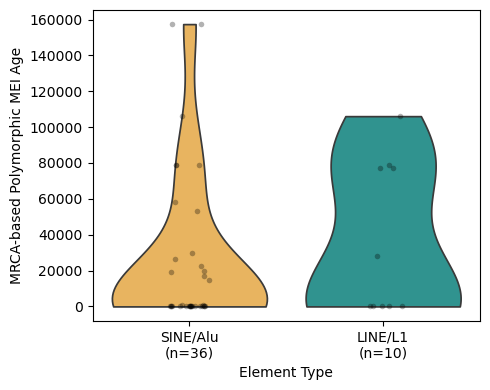

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

color_dict = {
    'LINE/L1': "#20a39e",
    'SINE/Alu': "#ffba49",
    "Retroposon/SVA": "#ef5b5b"
}

order = (
    plotDF.groupby("Element_Designation")["Age"]
    .median()
    .sort_values()
    .index
)

counts = plotDF["Element_Designation"].value_counts()

plt.figure(figsize=(5, 4))

sns.violinplot(
    data=plotDF,
    x="Element_Designation",
    y="Age",
    order=order,
    inner=None,
    palette=color_dict,
    cut=0
)

sns.stripplot(
    data=plotDF,
    x="Element_Designation",
    y="Age",
    order=order,
    size=4,
    color="black",
    alpha=0.3
)

new_labels = [
    f"{cat}\n(n={counts.get(cat, 0)})"
    for cat in order
]

plt.xticks(
    ticks=range(len(order)),
    labels=new_labels,
    rotation=0
)

plt.ylabel("MRCA-based Polymorphic MEI Age")
plt.xlabel("Element Type")

plt.tight_layout()
#plt.savefig("/chrY_element_age.pdf", bbox_inches="tight")
#plt.savefig("/chrY_element_age.jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
#plotDF.to_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_Polymorphic_MEI_FrozenCallElements.03262026.csv')

In [17]:
import numpy as np

def nucleotide_diversity_shared_sites(msa, missing={"-", "N", "n"}):
    n = len(msa)
    if n < 2:
        return np.nan

    L = len(msa[0])
    total_diffs = 0
    valid_sites = 0

    for pos in range(L):
        column = [seq[pos] for seq in msa]
        if any(base in missing for base in column):
            continue

        valid_sites += 1

        for i in range(n):
            for j in range(i + 1, n):
                if column[i] != column[j]:
                    total_diffs += 1

    comparisons = n * (n - 1) / 2

    if valid_sites == 0:
        return np.nan

    return total_diffs / (comparisons * valid_sites)

In [18]:
def read_fasta_msa(filepath):
    msa = []
    seq = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if seq:
                    msa.append("".join(seq))
                    seq = []
            else:
                seq.append(line)
        if seq:
            msa.append("".join(seq))

    lengths = set(len(s) for s in msa)
    if len(lengths) != 1:
        raise ValueError(f"Sequences are not equal length: {lengths}")

    return msa

In [19]:
import collections
variation = {}
directory='/LeeLab/HPRC/chromosomeY/Data/MEIs/deNovoSequences/aligned/'
for element, count in collections.Counter(meiDF['MainElement']).items():
    if count>1:
        mymsa = read_fasta_msa(directory+element+"_03212026_aligned.fasta")
        variation[element]=nucleotide_diversity_shared_sites(mymsa)
    else:
        variation[element]='SINGLETON'

FileNotFoundError: [Errno 2] No such file or directory: '/LeeLab/HPRC/chromosomeY/Data/MEIs/deNovoSequences/aligned/L1-43_03212026_aligned.fasta'

In [ ]:
meiDF.reset_index(inplace=True)
meiDF['nucleotide_diversity']='SINGLETON'
for row in meiDF.index:
    meiDF.at[row,'nucleotide_diversity']=variation[meiDF.at[row,'MainElement']]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

meiDF2 = meiDF[meiDF['nucleotide_diversity']!='SINGLETON'].copy()

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=meiDF2,
    x="Element_Designation",
    y="nucleotide_diversity",
    hue="ElementFreq",
    cut=0,             
    inner=None
)

sns.stripplot(
    data=meiDF2,
    x="Element_Designation",
    y="nucleotide_diversity",
    hue="ElementFreq",
    dodge=True,        
    size=4,
    alpha=0.4,
    color="black"
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(set(meiDF2["ElementFreq"]))],
           labels[:len(set(meiDF2["ElementFreq"]))],
           title="ElementFreq",
           bbox_to_anchor=(1.05, 1),
           loc="upper left")

plt.xlabel("Element Designation")
plt.ylabel("Nucleotide Diversity (π)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
alleleDF = meiDF[(meiDF['nucleotide_diversity']!='SINGLETON')].copy()
youngElements=['L1HS','L1PA2','AluYa5','AluYa8','AluYb9']
alleleDF1 = alleleDF[(alleleDF['Element_Annotation'].isin(youngElements))].copy()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

meiDF2 = alleleDF1.copy()

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=meiDF2,
    x="Element_Designation",
    y="nucleotide_diversity",
    hue="ElementFreq",
    cut=0,             
    inner=None
)

sns.stripplot(
    data=meiDF2,
    x="Element_Designation",
    y="nucleotide_diversity",
    hue="ElementFreq",
    dodge=True,        
    size=4,
    alpha=0.4,
    color="black"
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(set(meiDF2["ElementFreq"]))],
           labels[:len(set(meiDF2["ElementFreq"]))],
           title="ElementFreq",
           bbox_to_anchor=(1.05, 1),
           loc="upper left")

plt.xlabel("Element Designation")
plt.ylabel("Nucleotide Diversity (π)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
elementTreeDF.set_index("element_id", inplace=True)

In [ ]:
meiDF2['Age']=0
for row in meiDF2.index:
    element = meiDF2.at[row,'MainElement']
    if element in elementTreeDF.index:
        meiDF2.at[row,'Age'] = float(elementTreeDF.at[element, 'Age'])
    else:
        meiDF2.at[row,'Age'] = 185000

In [ ]:
fig=sns.scatterplot(
    data=meiDF2,
    x='nucleotide_diversity',
    y='Age',
    hue='ElementFreq',
    style='Element_Designation'
)
fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

In [ ]:
import re

def remove_trailing_numbers(s):
    return re.sub(r'\d+$', '', s)

meiDF2['SeqClassTrim']=[remove_trailing_numbers(x) for x in meiDF2['overlap_name_string']]

In [ ]:
fig=sns.scatterplot(
    data=meiDF2,
    x='nucleotide_diversity',
    y='Age',
    hue='ElementFreq',
    style='SeqClassTrim'
)
fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)